In [2]:
import numpy as np

In [1]:
class linreg:
    def __init__(self, alpha = 0.02, lambda_= 1e-5, iteration = 50):
        self.alpha = alpha
        self.lambda_ = lambda_
        self.w = None
        self.losses = []
        self.iter = iteration 
        self.tolerance = 1e-7

    def fit(self, X, y):
        assert X.ndim == 2
        assert y.ndim == 1 or y.ndim == 2
        assert X.shape[0] == y.shape[0]
        m,n = X.shape
        y = y[:, np.newaxis] # col vec
        self.w = np.zeros((n, 1)) # including bias

        for i in range(self.iter):
            predictions = X @ self.w
            error = predictions - y
            mse = (1/(2*m)) * np.sum(error**2)
            l2_norm = (self.lambda_ /(2*m)) * np.sum(self.w[1:] ** 2)
            loss = mse + l2_norm
            self.losses.append(loss)
            if i>0 and abs(self.losses[-1] - self.losses[-2])<self.tolerance:
                break
            grad = (1/m) * (X.T @ error) 
            grad[1:] += (self.lambda_/m)* self.w[1:]
            self.w = self.w - self.alpha*grad 

    def predict(self, X):
        return X @ self.w



# Generate Dummy Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate simple linear data
def generate_linear_data(n_samples=100, n_features=3, noise=0.1):
    """
    Generate synthetic linear regression data
    
    Parameters:
    - n_samples: number of data points
    - n_features: number of features (excluding bias)
    - noise: standard deviation of Gaussian noise
    
    Returns:
    - X: feature matrix with bias column (n_samples, n_features+1)
    - y: target vector (n_samples,)
    - true_w: true weights used to generate data
    """
    # Generate random features
    X = np.random.randn(n_samples, n_features)
    
    # Add bias column (column of ones)
    X = np.hstack([np.ones((n_samples, 1)), X])
    
    # Define true weights (including bias)
    true_w = np.array([2.0, 3.0, -1.5, 0.8])[:n_features+1]
    
    # Generate target with some noise
    y = X @ true_w + np.random.randn(n_samples) * noise
    
    return X, y, true_w

# Generate data
X_train, y_train, true_weights = generate_linear_data(n_samples=100, n_features=3, noise=0.5)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"True weights: {true_weights}")

X_train shape: (100, 4)
y_train shape: (100,)
True weights: [ 2.   3.  -1.5  0.8]


In [8]:
# Train the model
model = linreg(alpha=0.01, lambda_=0.01, iteration=1000)
model.fit(X_train, y_train)

In [9]:
# Make predictions
y_pred = model.predict(X_train)

# Evaluate
mse = np.mean((y_pred.ravel() - y_train)**2)
print(f"\nTraining Results:")
print(f"Iterations run: {len(model.losses)}")
print(f"Final loss: {model.losses[-1]:.6f}")
print(f"MSE: {mse:.6f}")


Training Results:
Iterations run: 974
Final loss: 0.095186
MSE: 0.189209


In [11]:
print(f"\nLearned weights:\n{model.w.ravel()}")


Learned weights:
[ 2.05746084  2.9560201  -1.52555499  0.74503806]


In [12]:
print(f"True weights:\n{true_weights}")
print(f"Weight difference:\n{np.abs(model.w.ravel() - true_weights)}")

True weights:
[ 2.   3.  -1.5  0.8]
Weight difference:
[0.05746084 0.0439799  0.02555499 0.05496194]


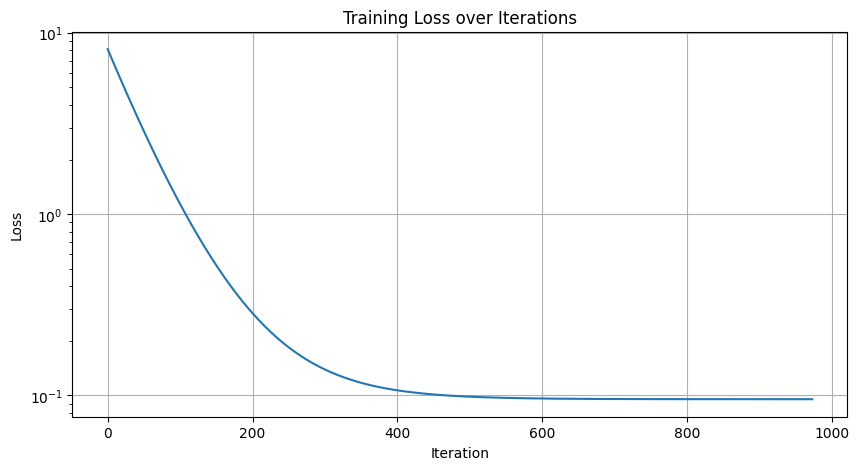

In [13]:
# Plot loss over iterations
plt.figure(figsize=(10, 5))
plt.plot(model.losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.grid(True)
plt.yscale('log')  # Log scale to see convergence better
plt.show()

In [15]:
class linreg_2:
    def __init__(self, alpha = 0.02, lambda_= 1e-5, iteration = 50):
        self.alpha = alpha
        self.lambda_ = lambda_
        self.w = None
        self.losses = []
        self.iter = iteration 
        self.tolerance = 1e-7

    def fit(self, X, y):
        assert X.ndim == 2
        assert y.ndim == 1 or y.ndim == 2
        assert X.shape[0] == y.shape[0]
        m,n = X.shape
        y = y[:, np.newaxis] # col vec
        self.w = np.zeros((n, 1)) 

        for i in range(self.iter):
            predictions = X @ self.w
            error = predictions - y
            mse = (1/(2*m)) * np.sum(error**2)
            l2_norm = (self.lambda_ /(2*m)) * np.sum(self.w ** 2)
            loss = mse + l2_norm
            self.losses.append(loss)
            if i>0 and abs(self.losses[-1] - self.losses[-2])<self.tolerance:
                break
            grad = (1/m) * (X.T @ error) + (self.lambda_/m)* self.w
            self.w = self.w - self.alpha*grad 

    def predict(self, X):
        return X @ self.w



In [19]:
# Train the model
model = linreg_2(alpha=0.01, lambda_=0.01, iteration=1000)
model.fit(X_train, y_train)

In [20]:
# Make predictions
y_pred = model.predict(X_train)

# Evaluate
mse = np.mean((y_pred.ravel() - y_train)**2)
print(f"\nTraining Results:")
print(f"Iterations run: {len(model.losses)}")
print(f"Final loss: {model.losses[-1]:.6f}")
print(f"MSE: {mse:.6f}")


Training Results:
Iterations run: 974
Final loss: 0.095397
MSE: 0.189209


In [21]:
print(f"\nLearned weights:\n{model.w.ravel()}")


Learned weights:
[ 2.05724499  2.95604757 -1.52559201  0.74504903]


In [22]:
print(f"True weights:\n{true_weights}")
print(f"Weight difference:\n{np.abs(model.w.ravel() - true_weights)}")

True weights:
[ 2.   3.  -1.5  0.8]
Weight difference:
[0.05724499 0.04395243 0.02559201 0.05495097]


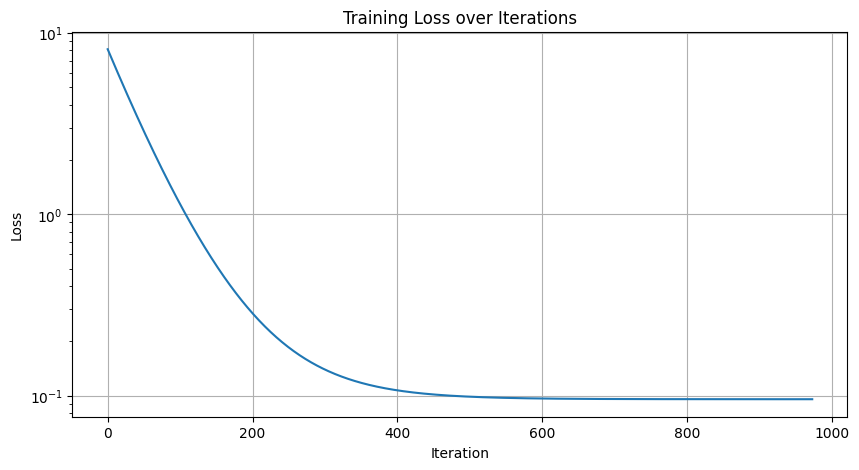

In [25]:
# Plot loss over iterations
plt.figure(figsize=(10, 5))
plt.plot(model.losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.grid(True)
plt.yscale('log')  # Log scale to see convergence better
plt.show()

In [17]:
class LinearReg_l1:
    def __init__(self, alpha = 1e-5, lambda_ = 1e-3):
        self.alpha = alpha
        self.lambda_ = lambda_
        self.theta = None
        self.bias = 0
        self.losses = []
        self.tolerance = 1e-7

    def fit(self, X, y, iterations = 100):
        assert X.ndim >=2 
        assert y.ndim == 1 or y.ndim ==2
        assert X.shape[0] == y.shape[0]

        m,n = X.shape
        self.theta = np.zeros((n,1))
        y = y[:, np.newaxis]

        for i in range(iterations):
            predictions = X @ self.theta + self.bias
            error = predictions - y
            mse = (1/(2*m)) * np.sum(error ** 2)
            l1_reg = self.lambda_ * np.sum(np.abs(self.theta))
            loss = mse + l1_reg
            self.losses.append(loss)

            if i>=1 and abs(self.losses[-1] - self.losses[-2]) <= self.tolerance:
                break

            grad = (1/m)* ( X.T @ error) + self.lambda_ * np.sign(self.theta)
            db = (1/m)*  np.sum(error)

            self.theta -= self.alpha * grad
            self.bias -= self.alpha * db

    def predict(self,X):
        return X @ self.theta + self.bias

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate simple linear data
def generate_linear_data(n_samples=100, n_features=3, noise=0.1):
    """
    Generate synthetic linear regression data
    
    Parameters:
    - n_samples: number of data points
    - n_features: number of features (excluding bias)
    - noise: standard deviation of Gaussian noise
    
    Returns:
    - X: feature matrix with bias column (n_samples, n_features+1)
    - y: target vector (n_samples,)
    - true_w: true weights used to generate data
    """
    # Generate random features
    X = np.random.randn(n_samples, n_features)
    
    # Add bias column (column of ones)
    #X = np.hstack([np.ones((n_samples, 1)), X])
    
    # Define true weights (including bias)
    true_w = np.array([3.0, -1.5, 0.8])[:n_features]
    
    # Generate target with some noise
    y = X @ true_w + np.random.randn(n_samples) * noise
    
    return X, y, true_w

# Generate data
X_train, y_train, true_weights = generate_linear_data(n_samples=100, n_features=3, noise=0.5)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"True weights: {true_weights}")
X_train, y_train, true_weights = generate_linear_data(n_samples=100, n_features=3, noise=0.5)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"True weights: {true_weights}")

X_train shape: (100, 3)
y_train shape: (100,)
True weights: [ 3.  -1.5  0.8]
X_train shape: (100, 3)
y_train shape: (100,)
True weights: [ 3.  -1.5  0.8]


In [19]:
# Train the model
model = LinearReg_l1(alpha=0.01, lambda_=0.01)
model.fit(X_train, y_train, iterations = 1000)

In [20]:
# Make predictions
y_pred = model.predict(X_train)

# Evaluate
mse = np.mean((y_pred.ravel() - y_train)**2)
print(f"\nTraining Results:")
print(f"Iterations run: {len(model.losses)}")
print(f"Final loss: {model.losses[-1]:.6f}")
print(f"MSE: {mse:.6f}")


Training Results:
Iterations run: 684
Final loss: 0.168009
MSE: 0.227932


In [22]:
print(f"\nLearned weights:\n{model.theta.ravel()}")
print(f"True weights:\n{true_weights}")
print(f"Weight difference:\n{np.abs(model.theta.ravel() - true_weights)}")


Learned weights:
[ 3.00566564 -1.55527327  0.84334866]
True weights:
[ 3.  -1.5  0.8]
Weight difference:
[0.00566564 0.05527327 0.04334866]


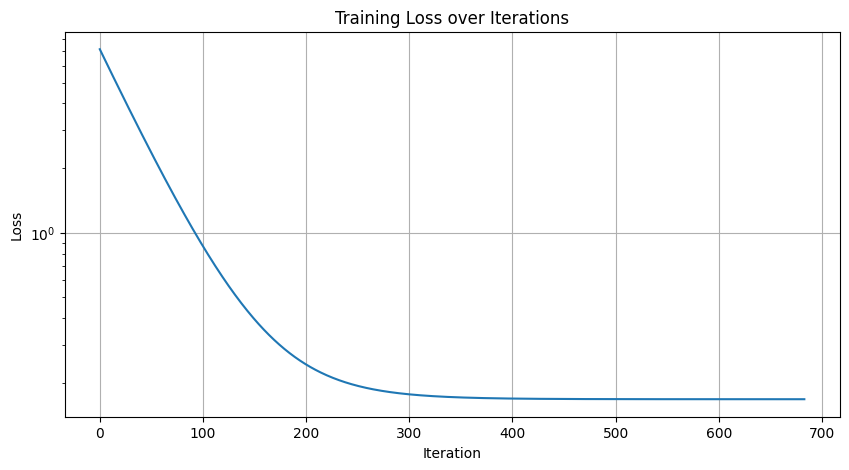

In [23]:
# Plot loss over iterations
plt.figure(figsize=(10, 5))
plt.plot(model.losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.grid(True)
plt.yscale('log')  # Log scale to see convergence better
plt.show()